We start with Wages Case and lin reg

In [1]:
# Import required packages 
import pandas as pd
import numpy as np

#Scikit
from sklearn.linear_model import LinearRegression #for lin reg
from sklearn.metrics import r2_score

import statsmodels.api as sm
from scipy import stats
import statsmodels.stats.diagnostic as dg
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import norm
import seaborn as sns
import statsmodels.graphics.tsaplots as gp
import statsmodels.stats.stattools as st


import os

targetDirectory = "C:\\CASES\\PYTPRA"
os.chdir(targetDirectory)
print("Working directory in use: ", os. getcwd())

Working directory in use:  C:\CASES\PYTPRA


In [2]:
### data is looked for in wd
df_WAGES = pd.read_csv('wages.txt', sep = "\t") #txt is tab separated, data from Verbeek, M. "A Guide to Modern Econometrics"
df_WAGES.head()

,EXPER,MALE,SCHOOL,WAGE
0,9,0,13,6.315296
1,12,0,12,5.479770
2,11,0,11,3.642170
3,9,0,14,4.593337
4,8,0,14,2.418157


In [3]:
#behave as if we were filling the world = we excute a data generating process
school = df_WAGES['SCHOOL']
school[2] #offset is zero, hence 3rd row and column SCHOOL
exper = df_WAGES['EXPER']
male = df_WAGES['MALE']

#scikit needs matrix of size n_samples, n_features (van der Plas, p 349)
print(school.shape)
a_school = np.array(school, dtype='float32')
a_school = a_school.reshape(school.size,1)
print(a_school.shape)
a_exper = np.array(exper, dtype='float32')
a_exper = a_exper.reshape(exper.size,1)
a_male = np.array(male, dtype='float32')
a_male = a_male.reshape(male.size,1)
print(a_male.shape)

#head of HR determines wages according to the following TOP SECRET FORMULA
a_wage_gen = -3.38 + 0.63 * a_school + 0.12 * a_exper + 1.34 * a_male  
print("First five wages are set as: \n", a_wage_gen[0:5,:])

#to hide that discrimination happens, a bit of noise is added to this equation
np.random.seed(2023)#make it reproducible
a_eps = np.random.normal(loc=0.0, scale=0.2, size=school.size)
a_eps = a_eps.reshape(school.size,1)
print("Mean of error term e:", round(a_eps.mean(),3))
print("Maximum of error term e:", round(a_eps.max(),3))
a_wage_gen = a_wage_gen + a_eps

a_X = np.hstack([a_school,a_exper,a_male])
a_X.shape

(3294,)
(3294, 1)
(3294, 1)
First five wages are set as: 
 [[5.8899994]
 [5.62     ]
 [4.87     ]
 [6.5199995]
 [6.3999996]]
Mean of error term e: -0.001
Maximum of error term e: 0.663


(3294, 3)

In [4]:
###############################################################################
#   LinReg Scikit
###############################################################################

wages_linreg_sk = LinearRegression().fit(a_X, a_wage_gen)
# Inspect the results
print("Estimated paras are")
print(wages_linreg_sk.intercept_)
print(wages_linreg_sk.coef_)
print("\n")
print("REG: R squared on data")
print(round(r2_score(a_wage_gen, wages_linreg_sk.predict(a_X)),3))

Estimated paras are
[-3.3390803]
[[0.626954   0.11917218 1.3396626 ]]


REG: R squared on data
0.973


In [5]:
###############################################################################
#   LinReg Statsmodels
###############################################################################

X = sm.add_constant(a_X)
wages_linreg_sm = sm.OLS(a_wage_gen, X)#reverse order of args
wages_linreg_sm_results = wages_linreg_sm.fit(cov_type='HAC',cov_kwds={'maxlags':1})
#menu: 'HC3', 'HAC', etc
wages_linreg_sm_results.params
# Inspect the results
print(wages_linreg_sm_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                 3.931e+04
Date:                Thu, 13 Feb 2025   Prob (F-statistic):               0.00
Time:                        13:55:11   Log-Likelihood:                 678.56
No. Observations:                3294   AIC:                            -1349.
Df Residuals:                    3290   BIC:                            -1325.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3391      0.030   -110.795      0.0

In [6]:
###############################################################################
#   LinReg Statsmodels
###############################################################################
#get real wages
wage = df_WAGES['WAGE']
a_wage = np.array(wage, dtype='float32')
a_wage = a_wage.reshape(wage.size,1)

X = sm.add_constant(a_X)
wages_linreg_sm = sm.OLS(a_wage, X)#reverse order of args
wages_linreg_sm_results = wages_linreg_sm.fit(cov_type='HAC',cov_kwds={'maxlags':1})
#menu: 'HC3', 'HAC', etc
wages_linreg_sm_results.params
# Inspect the results
print(wages_linreg_sm_results.summary())
print("\nXXX DONE XXX")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     154.7
Date:                Thu, 13 Feb 2025   Prob (F-statistic):           8.89e-94
Time:                        13:55:11   Log-Likelihood:                -8341.1
No. Observations:                3294   AIC:                         1.669e+04
Df Residuals:                    3290   BIC:                         1.671e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3800      0.468     -7.230      0.0

In [7]:
#HERE STARTS DIAGNOSTICS
print("\n--------------RESET - TEST------------------------------")
reset = dg.linear_reset(wages_linreg_sm_results, power = 4, test_type = 'fitted', use_f = True, )
print("\nRamsey RESET test with H0: Correct specs \n ")
print("F Statistic: ", np.round(reset.fvalue, 4))
print("P Value: ", np.round(reset.pvalue, 4))
#logic: with Rsq close to 100 percent the linear function is in question, not the X


--------------RESET - TEST------------------------------

Ramsey RESET test with H0: Correct specs 
 
F Statistic:  6.9707
P Value:  0.0001



--------------BP - TEST------------------------------
Breusch- Pagan Test-Statistik: 5.0280020333485316e-05
Test auf Normalverteilung der Residuen: 


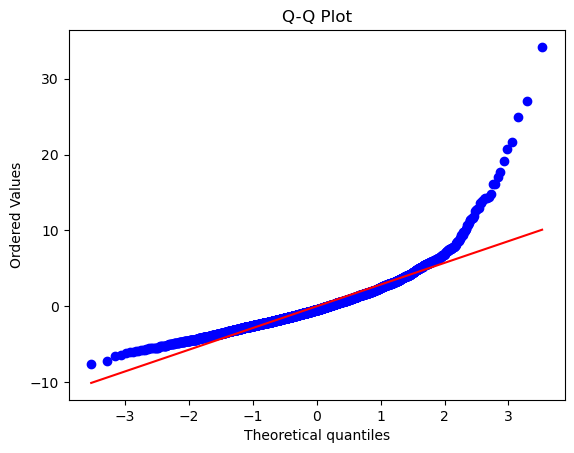

In [8]:
print("\n--------------BP - TEST------------------------------")#H0: Homo

X_train_df = pd.DataFrame(X)  #
X_train_temp = X_train_df
bp_test_statistic, bp_p_value, _, _ = dg.het_breuschpagan(wages_linreg_sm_results.resid, X_train_temp)
print("Breusch- Pagan Test-Statistik: " + str(bp_p_value))
print("Test auf Normalverteilung der Residuen: ")#BP needs it
stats.probplot(wages_linreg_sm_results.resid, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

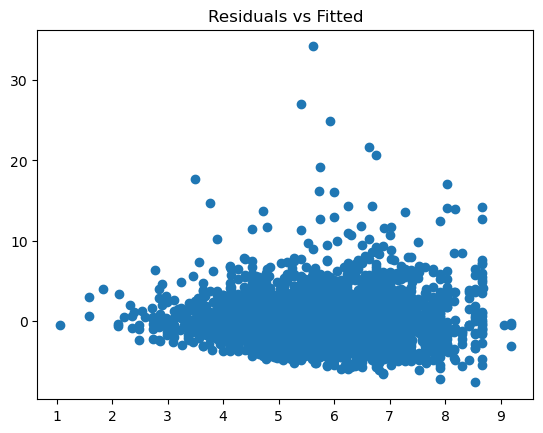

In [9]:
#any structure visible?
residuals = wages_linreg_sm_results.resid
y_fc = wages_linreg_sm_results.predict(X)
plt.scatter(y_fc, residuals)
plt.title('Residuals vs Fitted')
plt.show()

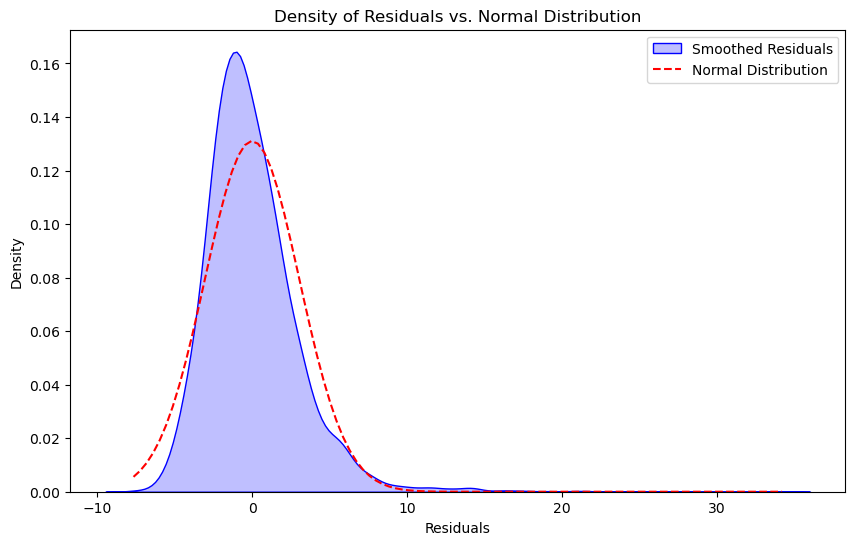

In [10]:
x_values = np.linspace(min(residuals), max(residuals), 100)

normal_density = norm.pdf(x_values, np.mean(residuals), np.std(residuals))

plt.figure(figsize=(10, 6))

sns.kdeplot(residuals, label='Smoothed Residuals', color='blue', fill=True)

plt.plot(x_values, normal_density, label='Normal Distribution', color='red', linestyle='--')

plt.title('Density of Residuals vs. Normal Distribution')

plt.xlabel('Residuals')

plt.ylabel('Density')

plt.legend()

plt.show()

In [11]:
print("\n--------------WHITE - TEST------------------------------")#H0: Homo, white does not need normality
white_test_statistic, white_p_value, _, _ = dg.het_white(wages_linreg_sm_results.resid, X_train_temp)
print("White Test-Statistik: " + str(white_p_value))


--------------WHITE - TEST------------------------------
White Test-Statistik: 0.0007347939938927816



--------------AUTOCORR - TEST------------------------------


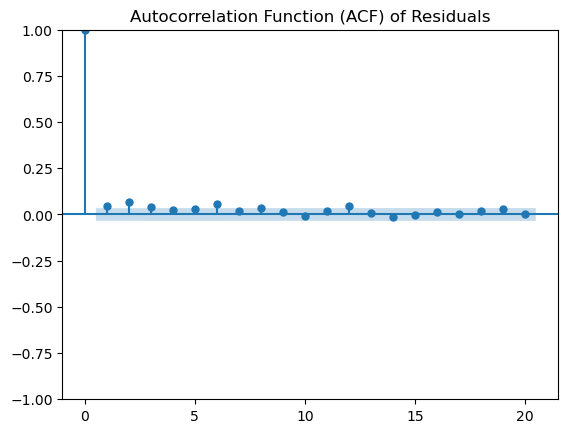

Durbin-Watson Test-Statistik: 1.905052153492465


In [12]:
print("\n--------------AUTOCORR - TEST------------------------------")

#not sensible here
residuals = wages_linreg_sm_results.resid
gp.plot_acf(residuals, lags=20)
plt.title('Autocorrelation Function (ACF) of Residuals')
plt.show()  

dw = st.durbin_watson(wages_linreg_sm_results.resid)
print("Durbin-Watson Test-Statistik: " + str(dw))

In [13]:
# Multikoll - VIF
print("\n--------------VIF Redundancies------------------------------")

X_train_df = pd.DataFrame(a_X)  #
X_train_temp = X_train_df
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train_temp, i) for i in range(X_train_temp.shape[1])]
vif["features"] = X_train_temp.columns

print("\nVIF-Test Ergebnisse:")
print(vif)



--------------VIF Redundancies------------------------------

VIF-Test Ergebnisse:
   VIF Factor  features
0    9.400949         0
1    9.836997         1
2    2.103201         2


In [14]:
#conclusion, could use only white H0 instead of HAC
ols_results_hc = wages_linreg_sm.fit(cov_type='HC0')
print(ols_results_hc.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     158.4
Date:                Thu, 13 Feb 2025   Prob (F-statistic):           6.84e-96
Time:                        13:55:12   Log-Likelihood:                -8341.1
No. Observations:                3294   AIC:                         1.669e+04
Df Residuals:                    3290   BIC:                         1.671e+04
Df Model:                           3                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3800      0.462     -7.318      0.0

In [15]:
print("DONE")

DONE
